In [46]:
import sys
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import pickle
import random

print("Python excecutable:", sys.executable)

sys.path.append(str(Path.cwd().parent))
from src.simulation import (
    simulate_sir,
    choose_immunized_random,
    choose_immunized_by_degree,
    choose_immunized_by_eigenvector_centrality,
    choose_immunized_by_betweenness_centrality,
    choose_immunized_by_adaptive_degree,
    choose_immunized_by_highest,
    choose_immunized_by_neighbor_nomination,
)
from src.data_processing import load_wy_county_graphs


Python excecutable: /Users/nemodelingat/miniconda3/envs/ffg/bin/python3.11


In [28]:
base = "../data/WY/56003"
B, G_p = load_wy_county_graphs(base)

print("bipartite:", B.number_of_nodes(), B.number_of_edges())
print("person-person:", G_p.number_of_nodes(), G_p.number_of_edges())


bipartite: 14171 17531
person-person: 9780 358231


In [34]:
print(G.nodes)

['P:164165878', 'P:164165879', 'P:292941609', 'P:164165893', 'P:164165892', 'P:224872863', 'P:164848508', 'P:164848509', 'P:364669389', 'P:236728284', 'P:191696074', 'P:200842173', 'P:210113759', 'P:214143149', 'P:248582792', 'P:269911762', 'P:276216337', 'P:318016745', 'P:319438479', 'P:330504146', 'P:359544391', 'P:359656785', 'P:359675308', 'P:413523047', 'P:134533031', 'P:162914666', 'P:176362203', 'P:191773373', 'P:196749162', 'P:208837054', 'P:329136360', 'P:351606607', 'P:373081762', 'P:391068817', 'P:160568809', 'P:165192096', 'P:165192097', 'P:165192098', 'P:165192099', 'P:184254780', 'P:208603180', 'P:215175685', 'P:247533312', 'P:279618329', 'P:308526991', 'P:314610759', 'P:352792920', 'P:354040329', 'P:380934051', 'P:387777004', 'P:403917680', 'P:409669790', 'P:410622688', 'P:417356968', 'P:417492311', 'P:131820201', 'P:140954500', 'P:155017924', 'P:214992934', 'P:222084110', 'P:300001946', 'P:126729318', 'P:129945539', 'P:137688617', 'P:137700126', 'P:166308182', 'P:181978

In [3]:
largest_nodes = max(nx.connected_components(G_p), key=len)
G_sub = G_p.subgraph(largest_nodes).copy()
print(G_sub.number_of_nodes())

largest_nodes = max(nx.connected_components(G_sub), key=len)
G_sub = G_p.subgraph(largest_nodes).copy()
print(G_sub.number_of_nodes())

28901
28901


In [33]:
n = 400
p = 0.01
#G = nx.erdos_renyi_graph(n, p)  # undirected random graph
G = G_p
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Avg degree:", sum(dict(G.degree()).values()) / n)


Nodes: 9780
Edges: 358231
Avg degree: 1791.155


In [2]:
#with open("../data/WY_graphs.pkl", "rb") as f:
#    WY_graphs = pickle.load(f)

KeyboardInterrupt: 

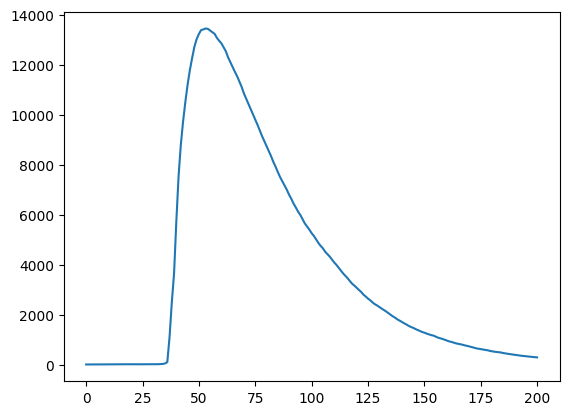

In [10]:
k = 2000
immunized_by_highest = choose_immunized_by_highest(G, k)

initial_infected = ['P:164104833']          # seed infection at node 0
out_deg_h = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=immunized_by_highest,
    rng=np.random.default_rng(42)
)

plt.plot(out_deg_h["I"], label=f"High Degree immunization (k={k})")

9780


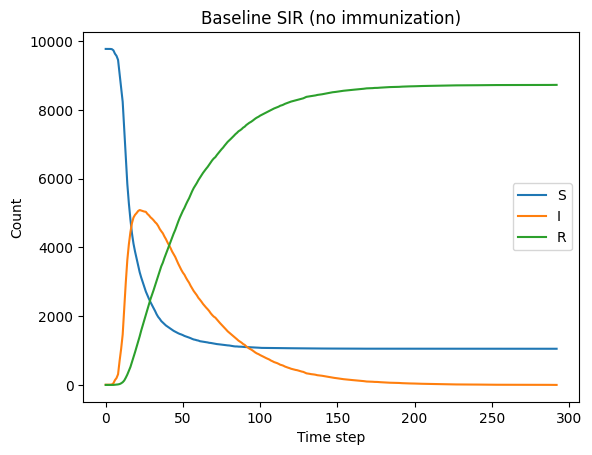

In [51]:
beta = 0.03 # probability of getting infected
gamma = 0.03 # probability of recovering
steps = 1000

largest_nodes = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_nodes).copy()
print(G_sub.number_of_nodes())

initial_infected = random.sample([n for n in list(G.nodes) if n not in immunized],6)

#initial_infected = ['P:164165878']          # seed infection at node 0
#initial_infected =[0]
rng = np.random.default_rng(42) # reproducible run

out0 = simulate_sir(
    G_sub,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=set(),
    rng=rng
)

total_inf = out0["Total_inf"]
plt.plot(out0["S"], label="S")
plt.plot(out0["I"], label="I")
plt.plot(out0["R"], label="R")

plt.title("Baseline SIR (no immunization)")
plt.xlabel("Time step")
plt.ylabel("Count")
plt.legend()
plt.show()

In [60]:
k = 1000
beta = 0.03 # probability of getting infected
gamma = 0.03 # probability of recovering
steps = 300

strategy_functions = {
    "Random": choose_immunized_random,
    "Degree": choose_immunized_by_degree,
    "Eigenvector": choose_immunized_by_eigenvector_centrality,
    "Adaptive Degree": choose_immunized_by_adaptive_degree,
    "Highest": choose_immunized_by_highest,
    "Neighbor Nomination": choose_immunized_by_neighbor_nomination,
}

N_infected = 10
out_by_strategy = {}
for name, fn in strategy_functions.items():
    immunized = fn(G, k)
    infected = random.sample([n for n in list(G.nodes) if n not in immunized], N_infected)
    print(infected)
    out_by_strategy[name] = simulate_sir(
        G,
        beta=beta,
        gamma=gamma,
        steps=steps,
        initial_infected=infected,
        immunized=immunized,
        rng=np.random.default_rng(42),
    )
    print("strategy: " + name)


['P:130015918', 'P:373226728', 'P:404603623', 'P:364446301', 'P:355640581', 'P:359056992', 'P:239866824', 'P:176886608', 'P:238301405', 'P:416369032']
strategy: Random
['P:154633445', 'P:238142843', 'P:373226462', 'P:399271711', 'P:208267013', 'P:271526199', 'P:413511842', 'P:288855967', 'P:222425570', 'P:183938260']
strategy: Degree
['P:394220632', 'P:163647963', 'P:374656803', 'P:408442832', 'P:343235391', 'P:381985435', 'P:234212081', 'P:322154998', 'P:166464206', 'P:213518706']
strategy: Eigenvector
['P:242841219', 'P:215160349', 'P:255156376', 'P:386354162', 'P:242198995', 'P:248582792', 'P:168660765', 'P:411066806', 'P:357801639', 'P:210101018']
strategy: Adaptive Degree
['P:278333399', 'P:328381090', 'P:303258795', 'P:409149261', 'P:298919878', 'P:275220885', 'P:145301355', 'P:371828310', 'P:413523095', 'P:134532962']
strategy: Highest
['P:416055098', 'P:359107786', 'P:218358665', 'P:415878361', 'P:380934057', 'P:250452635', 'P:286813507', 'P:399271516', 'P:244712159', 'P:286334

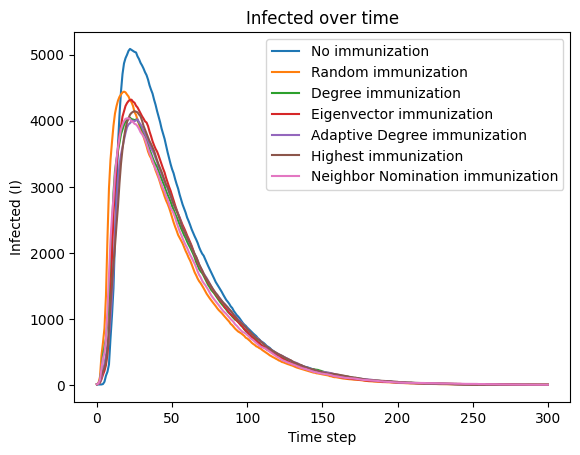

In [58]:
plt.plot(out0["I"], label="No immunization")
for name, out in out_by_strategy.items():
    plt.plot(out["I"], label=f"{name} immunization")

plt.title("Infected over time")
plt.xlabel("Time step")
plt.ylabel("Infected (I)")
plt.legend()
plt.show()


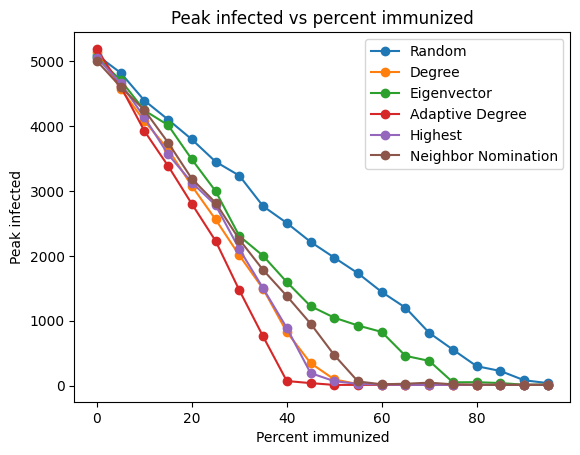

In [68]:
def peak_infected(out):
    return max(out["I"])
def total_infected(out):
    return out["Total_inf"]

k_percentages = list(range(0, 100, 5))
peak_by_strategy = {name: [] for name in strategy_functions}
total_by_strategy = {name: [] for name in strategy_functions}
for k_pct in k_percentages:
      k_count = math.floor(k_pct * len(G.nodes) / 100)

      for name, fn in strategy_functions.items():
          immunized = fn(G, k_count)

          eligible = [n for n in G.nodes if n not in immunized]
          seed_count = min(N_infected, len(eligible))
          infected = random.sample(eligible, seed_count)

          out = simulate_sir(
              G,
              beta=beta,
              gamma=gamma,
              steps=steps,
              initial_infected=infected,
              immunized=immunized,
              rng=np.random.default_rng(42),
          )

          peak_by_strategy[name].append(max(out["I"]))
          total_by_strategy[name].append(out["Total_inf"])
        
for name, peaks in peak_by_strategy.items():
    plt.plot(k_percentages, peaks, marker="o", label=name)

plt.title("Peak infected vs percent immunized")
plt.xlabel("Percent immunized")
plt.ylabel("Peak infected")
plt.legend()
plt.show()


In [10]:
for name, out in out_by_strategy.items():
    print(f"{name}: Total_inf={out['Total_inf']}")


NameError: name 'out0' is not defined

In [ ]:
print(len(G.nodes))